# ✈️ Flight Price Analysis

Целью этого проекта является анализ датасета.

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
path_to_data = 'https://raw.githubusercontent.com/FragileMouse/flight-price-analysis/refs/heads/main/data/Clean_Dataset.csv'

df = pd.read_csv(path_to_data, index_col = 0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


# Описательная статистика

In [130]:
cat_mask = df.dtypes == 'object'

print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')
print(f'Количество числовых столбцов: {len((df.loc[:, ~cat_mask]).columns)}')
print(f'Наименования числовых столбцов: {list((df.loc[:, ~cat_mask]).columns)}')
print(f'Количество категориальных столбцов: {len((df.loc[:, cat_mask]).columns)}')
print(f'Наименования категориальных столбцов: {list((df.loc[:, cat_mask]).columns)}')
print(f'Количество дубликатов: {df.duplicated().sum()}')
print(f'Количество пропусков: {df.isna().sum().sum()}')

Количество строк: 300153
Количество столбцов: 11
Количество числовых столбцов: 3
Наименования числовых столбцов: ['duration', 'days_left', 'price']
Количество категориальных столбцов: 8
Наименования категориальных столбцов: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
Количество дубликатов: 0
Количество пропусков: 0


## Числовые значения

In [136]:
df.describe().round(2)

,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


<Axes: title={'center': 'Распределение длительности полета'}, xlabel='Часы', ylabel='Количество записсей'>

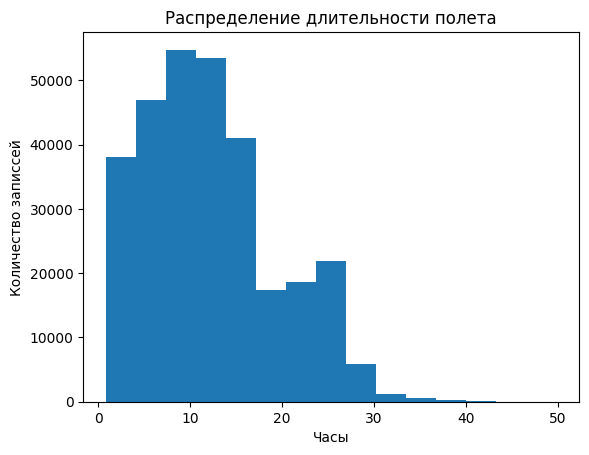

In [162]:
df['duration'].plot.hist(
    bins=15,
    title = 'Распределение длительности полета',
    xlabel = 'Часы',
    ylabel = 'Количество записей'
    )

**duration**. Минимальное время полета 0,83 часа (50 минут). Максимальное время полета 50 часов. В теории такое возможно, если были остановки. Но вообще говоря сомнительно для внутренних индийских рейсов... Пока оставим. Среднее и медиана всего на час различаются. В целом большее количество коротких полетов. Но время полетов как-то настораживает.

<Axes: title={'center': 'Разница между датой поездки и датой бронирования'}, xlabel='Количество дней до поездки', ylabel='Количество записей'>

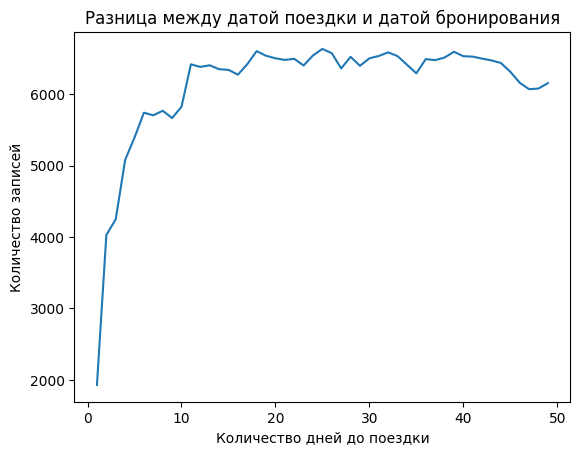

In [159]:
df['days_left'].value_counts().sort_index().plot(
    title = 'Разница между датой поездки и датой бронирования',
    xlabel = 'Количество дней до поездки',
    ylabel = 'Количество записей'
)

**days_left**. Как правило, люди планируют свои поездки чуть заранее (хотя бы за неделю до). Распределение +- равномерное. Разброс от 1 до 50 дней.

<Axes: title={'center': 'Распределение длительности полета'}, xlabel='Часы', ylabel='Количество записей'>

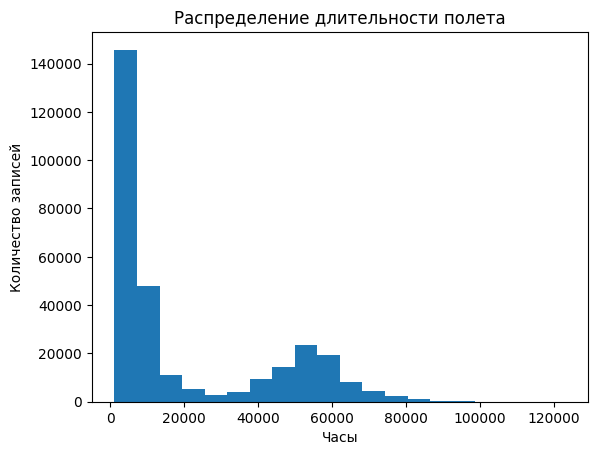

In [166]:
df['price'].plot.hist(
    bins=20,
    title = 'Распределение длительности полета',
    xlabel = 'Часы',
    ylabel = 'Количество записей'
)

**price**. Поскольку у нас по сути смешались две выборки, мы наблюдаем бимодальность. Имеет смысл в дальнейшем рассматривать отдельно каждую категорию.

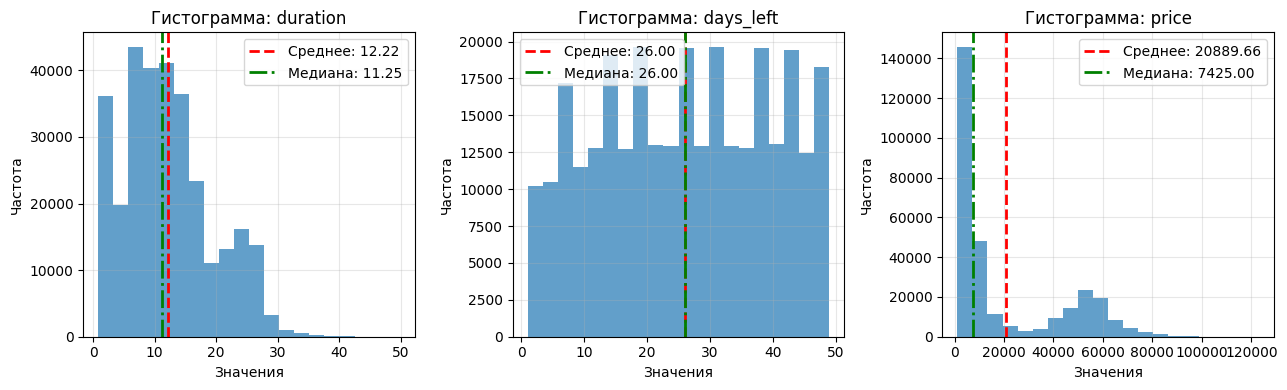

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(list((df.loc[:, ~cat_mask]).columns)):
    axes[i].hist(df[col], bins=20, alpha=0.7)

    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Медиана: {median_val:.2f}')

    axes[i].set_title(f'Гистограмма: {col}')
    axes[i].set_xlabel('Значения')
    axes[i].set_ylabel('Частота')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Номинальные значения

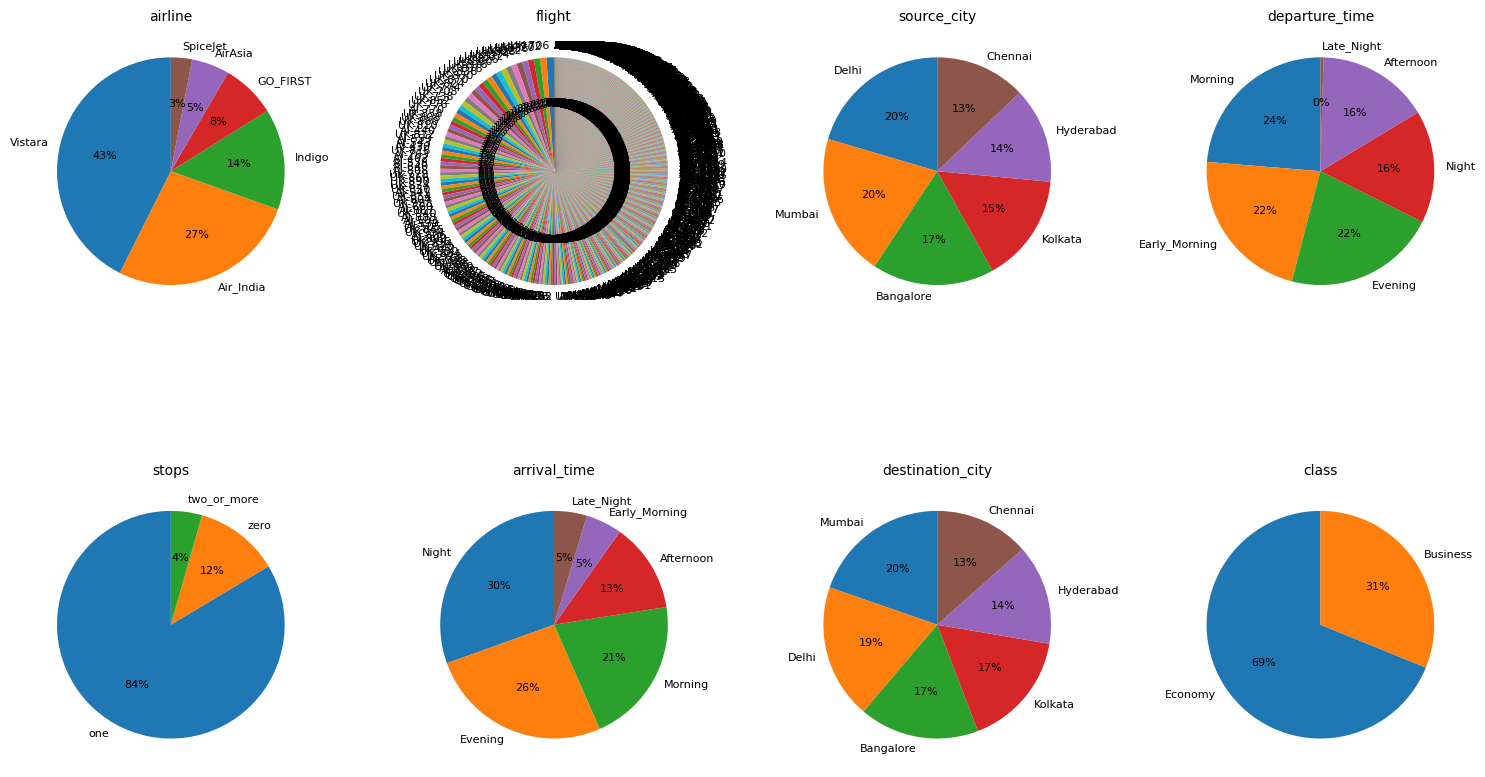

In [179]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(list((df.loc[:, cat_mask]).columns)):
    values = df[col].value_counts()
    axes[i].pie(values, labels=values.index, autopct='%1.0f%%',
                startangle=90, textprops={'fontsize': 8})
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

Обратим внимание на flight - очень много уникальных значений, однако информации практически не дает: авиакомпания у нас отдельной переменной, маршруты тоже... Получается можем удалить и не мучиться.

In [180]:
del df['flight']

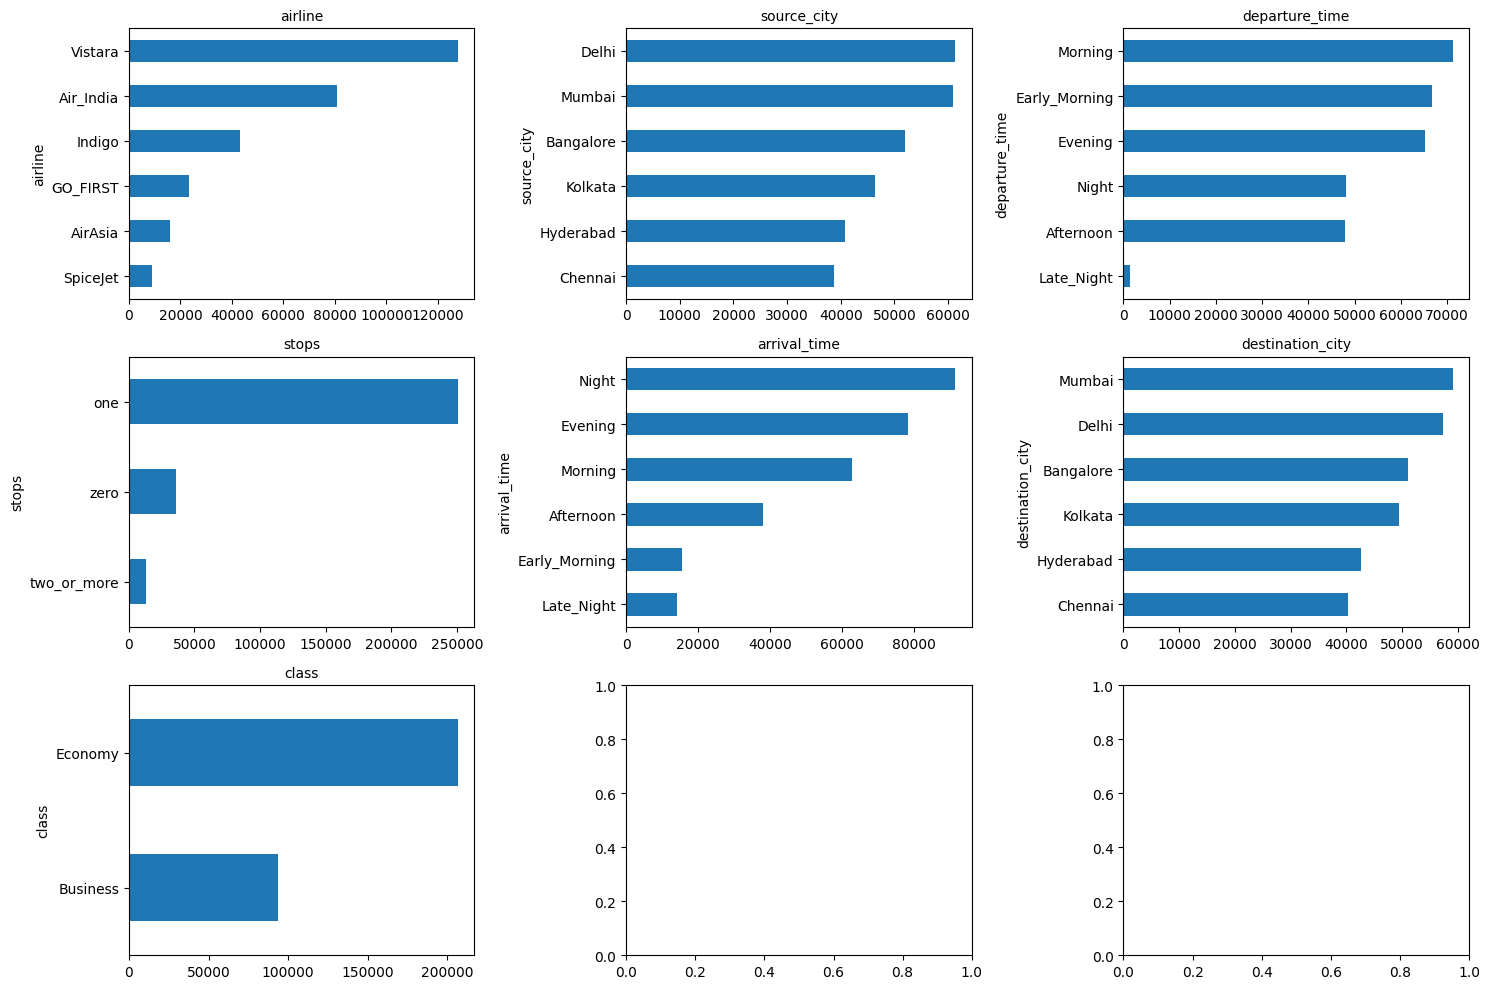

In [191]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(list((df.loc[:, cat_mask]).columns)):
    row = i // 3
    col_idx = i % 3
    df[col].value_counts(sort=True, ascending=True).plot.barh(ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col, fontsize=10)


plt.tight_layout()
plt.show()

#Зависит ли цена от авиакомпании?

Хочется сразу разграничить эконом и бизнес класс.

array([<Axes: ylabel='Business'>, <Axes: ylabel='Economy'>], dtype=object)

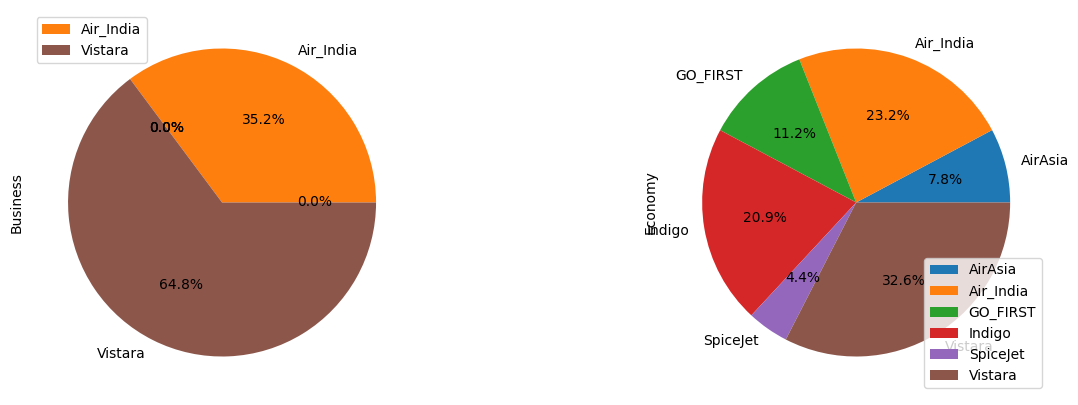

In [227]:
df.groupby(['airline', 'class']).size().unstack('class').plot.pie(subplots=True, figsize=(15, 5), autopct='%1.1f%%')

In [216]:
price_avialine = df.groupby('airline')['price'].describe()
price_avialine_dif = df.groupby(['class', 'airline'])['price'].describe()

display(price_avialine)
print('='*100)
display(price_avialine_dif)

,count,mean,std,min,25%,50%,75%,max
airline,,,,,,,,
AirAsia,16098.0,4091.072742,2824.055172,1105.0,2361.0,3276.0,4589.0,31917.0
Air_India,80892.0,23507.019112,20905.116909,1526.0,5623.0,11520.0,45693.0,90970.0
GO_FIRST,23173.0,5652.007595,2513.865560,1105.0,4205.0,5336.0,6324.0,32803.0
Indigo,43120.0,5324.216303,3268.894831,1105.0,3219.0,4453.0,6489.0,31952.0
SpiceJet,9011.0,6179.278881,2999.630406,1106.0,4197.0,5654.0,7412.0,34158.0
Vistara,127859.0,30396.536302,25637.159445,1714.0,6412.0,15543.0,55377.0,123071.0


count          mean           std      min      25%  \
class    airline                                                            
Business Air_India  32898.0  47131.039212  10521.926556  12000.0  42457.0   
         Vistara    60589.0  55477.027777  13225.349062  17604.0  49207.0   
Economy  AirAsia    16098.0   4091.072742   2824.055172   1105.0   2361.0   
         Air_India  47994.0   7313.682169   3989.521406   1526.0   4556.0   
         GO_FIRST   23173.0   5652.007595   2513.865560   1105.0   4205.0   
         Indigo     43120.0   5324.216303   3268.894831   1105.0   3219.0   
         SpiceJet    9011.0   6179.278881   2999.630406   1106.0   4197.0   
         Vistara    67270.0   7806.943645   3854.572559   1714.0   5206.0   

                        50%      75%       max  
class    airline                                
Business Air_India  49613.0  54608.0   90970.0  
         Vistara    56588.0  62591.0  123071.0  
Economy  AirAsia     3276.0   4589.0   31917.0  
         Air_India   6082.0   9135.0   42349.0  
         GO_FIRST    5336.0   6324.0   32803.0  
         Indigo      4453.0   6489.0   31952.0  
         SpiceJet    5654.0   7412.0   34158.0  
         Vistara     6461.0   9945.0   37646.0

<Axes: ylabel='class,airline'>

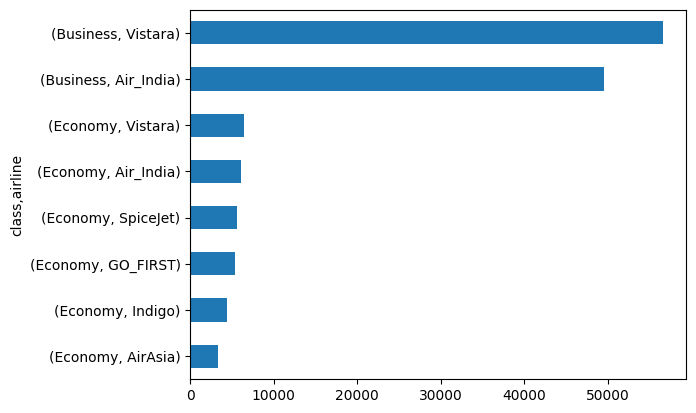

In [232]:
price_avialine_dif['50%'].sort_values(ascending=True).plot.barh()

<Axes: xlabel='airline', ylabel='price'>

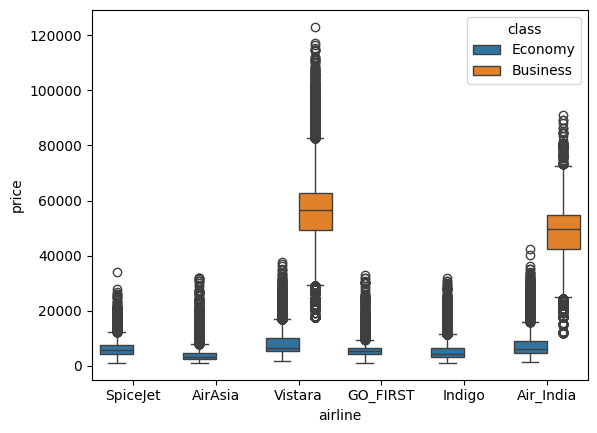

In [234]:
sns.boxplot(data=df, x='airline', y='price', hue='class')

AirIndia и Vistara в среднем будут дороже, поскольку, в отличие от других компаний, предоставляют бизнес-перелеты.
Если говорить по компаниям, то **Vistara в целом более премиальная**. В эконом сегменте же цены сильно разняться в разных компаниях.